In [1]:
%%capture
!apt-get update -y
!apt-get install -y libfftw3-dev nvidia-cuda-toolkit
!ln -s /usr/local/cuda/bin/nvcc /usr/local/bin/nvcc 2>/dev/null || true

In [2]:
%%capture
!apt-get update -y
!apt-get install -y libfftw3-mpi-dev libopenmpi-dev

In [3]:
!nvcc --version
!dpkg -s libfftw3-dev | grep Status

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Status: install ok installed


### Serial solution ##

In [4]:
%%writefile KSE_Serial_Solver.c

#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <complex.h>
#include <fftw3.h>
#include <time.h>

#define M_PI     3.14159265358979323846
#define N        32768         
#define L        (32.0*M_PI)         
#define DT       0.1
#define NSTEPS   3000
#define SAVE_EVERY 10


static double x[N];           
static double k[N];  
static fftw_complex u_hat[N];      
static fftw_complex u_phys[N];    

static fftw_plan plan_fwd;   
static fftw_plan plan_bwd;    
static fftw_complex Lk[N];          
static fftw_complex E[N], E2[N];
static fftw_complex Q[N], f1[N], f2[N], f3[N]; 



void init_grid(void) {
    const double dx = L / (double)N; 
    const double k_factor = (2.0*M_PI)/L; 
    for(int i=0; i<N; i++){
        x[i] = i*dx;
    }

    for(int i=0; i<N/2; i++){
        k[i] = i*k_factor; 
    }
    for(int i=N/2; i<N; i++){
        k[i] = (i-N)*k_factor; 
    }
    
}

void init_condition(void) {
    for(int i=0; i<N; i++){
        u_phys[i] = cos(x[i]/16.0)*(1+sin(x[i]/16.0)); 
    }
    fftw_execute(plan_fwd);
    for (int i = 0; i < N; i++) u_hat[i] = u_phys[i];
}

void compute_linear_operator(void) {
    for (int i = 0; i < N; i++) {
        double k2 = k[i]*k[i];
        Lk[i] = k2 - (k2*k2);
    }
}


void compute_etdrk4_coefficients(void) {
    const int M = 32;
    const double R = 1.0;
    for (int i = 0; i < N; i++) {
        double complex z = Lk[i] * DT;

        E[i]  = cexp(z);
        E2[i] = cexp(z / 2.0);

        double complex sum_Q  = 0.0;
        double complex sum_f1 = 0.0;
        double complex sum_f2 = 0.0;
        double complex sum_f3 = 0.0;

        for (int j = 0; j < M; j++) {
            
            double theta = 2.0 * M_PI * ((double)j + 0.5) / (double)M;
            double complex r = z + R * cexp(I * theta);

            double complex exp_r_half = cexp(r / 2.0);
            double complex exp_r      = cexp(r);
            double complex r2         = r * r;
            double complex r3         = r2 * r;

            sum_Q  += (exp_r_half - 1.0) / r;
            sum_f1 += (-4.0 - r + exp_r * (4.0 - 3.0 * r + r2)) / r3;
            sum_f2 += (2.0 + r + exp_r * (-2.0 + r)) / r3;
            sum_f3 += (-4.0 - 3.0 * r - r2 + exp_r * (4.0 - r)) / r3;
        }

        Q[i]  = DT * (sum_Q  / (double)M);
        f1[i] = DT * (sum_f1 / (double)M);
        f2[i] = DT * (sum_f2 / (double)M);
        f3[i] = DT * (sum_f3 / (double)M);
    }
}

void compute_nonlinear(fftw_complex *u_in_hat, fftw_complex *N_out_hat) {
    for (int i = 0; i < N; i++) {
        u_phys[i] = u_in_hat[i];
    }
    fftw_execute(plan_bwd);

    for (int i = 0; i < N; i++) {
        double u_val = creal(u_phys[i]) / (double)N;
        u_phys[i] = u_val * u_val;
    }

    fftw_execute(plan_fwd);

    for (int i = 0; i < N; i++) {
        N_out_hat[i] = -0.5 * I * k[i] * u_phys[i];
    }

    int kcut = N / 3;
    for (int i = 0; i < N; i++) {
        int dist = (i <= N/2) ? i : (N - i);
        if (dist > kcut) {
            N_out_hat[i] = 0.0;
        }
    }
}


void etdrk4_step(void) {
    static fftw_complex Nu[N], Na[N], Nb[N], Nc[N];
    static fftw_complex a[N], b[N], c[N];


    compute_nonlinear(u_hat, Nu);
    for (int i = 0; i < N; i++) {
        a[i] = E2[i] * u_hat[i] + Q[i] * Nu[i];
    }

    compute_nonlinear(a, Na);
    for (int i = 0; i < N; i++) {
        b[i] = E2[i] * u_hat[i] + Q[i] * Na[i];
    }

    compute_nonlinear(b, Nb);
    for (int i = 0; i < N; i++) {
        c[i] = E2[i] * a[i] + Q[i] * (2.0 * Nb[i] - Nu[i]);
    }

    compute_nonlinear(c, Nc);

    for (int i = 0; i < N; i++) {
        u_hat[i] = E[i] * u_hat[i] 
                 + Nu[i] * f1[i] 
                 + 2.0 * (Na[i] + Nb[i]) * f2[i] 
                 + Nc[i] * f3[i];
    }
}


void save_snapshot(FILE *fp, int step) {
    fftw_complex tmp[N];
    for (int i = 0; i < N; i++) tmp[i] = u_hat[i];
    fftw_execute_dft(plan_bwd, tmp, tmp);  

    fprintf(fp, "%d", step);
    for (int i = 0; i < N; i++) {
        double val = creal(tmp[i]) / N;    
        fprintf(fp, ",%f", val);
    }
    fprintf(fp, "\n");
}


int main(void) {

    clock_t start = clock();
    
    plan_fwd = fftw_plan_dft_1d(N, u_phys, u_phys, FFTW_FORWARD, FFTW_ESTIMATE);
    plan_bwd = fftw_plan_dft_1d(N, u_phys, u_phys, FFTW_BACKWARD, FFTW_ESTIMATE);

    init_grid();
    compute_linear_operator();
    compute_etdrk4_coefficients();
    init_condition();

    FILE *fp = fopen("kse_output.csv", "w");
    if (!fp) { perror("fopen"); return 1; }
    
    for (int step = 0; step < NSTEPS; step++) {
        etdrk4_step();
        if (step % SAVE_EVERY == 0) {
            save_snapshot(fp, step);
        }
    }
    clock_t end = clock();
    double serial_time = (double)(end - start) / CLOCKS_PER_SEC;

    printf("Serial Execution Time: %f seconds\n", serial_time);

    fclose(fp);
    fftw_destroy_plan(plan_fwd);
    fftw_destroy_plan(plan_bwd);

    printf("Done. Output written to kse_output.csv\n");
    printf("Plot it (e.g. Python: pcolormesh) and check for chaotic,\n");
    printf("non-blowing-up behavior as a first sanity check.\n");

    return 0;
}

/*gcc -O3 KSE_Serial_Solver.c -o kse_serial -lfftw3 -lm
./kse_serial*/

Writing KSE_Serial_Solver.c


In [5]:
!gcc -O3 KSE_Serial_Solver.c -o kse_serial -lfftw3 -lm
!./kse_serial

Serial Execution Time: 21.242926 seconds
Done. Output written to kse_output.csv
Plot it (e.g. Python: pcolormesh) and check for chaotic,
non-blowing-up behavior as a first sanity check.


### OMP Solution ###

In [6]:
%%writefile KSE_OMP_Solver.c

#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <complex.h>
#include <fftw3.h>
#include <omp.h>

#define M_PI     3.14159265358979323846
#define N        32768
#define L        (32.0*M_PI)
#define DT       0.1
#define NSTEPS   3000
#define SAVE_EVERY 10

static double x[N];
static double k[N];
static fftw_complex u_hat[N];
static fftw_complex u_phys[N];

static fftw_plan plan_fwd;
static fftw_plan plan_bwd;

static fftw_complex Lk[N];
static fftw_complex E[N], E2[N];
static fftw_complex Q[N], f1[N], f2[N], f3[N];


void init_fftw_threads(void) {
    if (!fftw_init_threads()) {
        fprintf(stderr, "Error: fftw_init_threads() failed. Multi-threaded FFTW could not be initialized.\n");
        exit(EXIT_FAILURE);
    }
    fftw_plan_with_nthreads(omp_get_max_threads());
}

void init_grid(void) {
    const double dx = L / (double)N;
    const double k_factor = (2.0*M_PI)/L;
    #pragma omp parallel
    {
        #pragma omp for
        for(int i=0; i<N; i++){
            x[i] = i*dx;
        }


        #pragma omp for
        for(int i=0; i<N/2; i++){
            k[i] = i*k_factor;
        }
        
        #pragma omp for
        for(int i=N/2; i<N; i++){
            k[i] = (i-N)*k_factor;
        }
    }
}

void init_condition(void) {
    #pragma omp parallel for
    for(int i=0; i<N; i++){
        u_phys[i] = cos(x[i]/16.0)*(1+sin(x[i]/16.0));
    }
    fftw_execute(plan_fwd);
    #pragma omp parallel for
    for (int i = 0; i < N; i++) u_hat[i] = u_phys[i];
}

void compute_linear_operator(void) {
    #pragma omp parallel 
    {
        #pragma omp for
        for (int i = 0; i < N; i++) {
            double k2 = k[i]*k[i];
            Lk[i] = k2 - (k2*k2);
        }
    }
}

void compute_etdrk4_coefficients(void) {
    const int M = 32;
    const double R = 1.0;

    #pragma omp parallel for
    for (int i = 0; i < N; i++) {
        double complex z = Lk[i] * DT;
        E[i]  = cexp(z);
        E2[i] = cexp(z / 2.0);

        double complex sum_Q  = 0.0;
        double complex sum_f1 = 0.0;
        double complex sum_f2 = 0.0;
        double complex sum_f3 = 0.0;

        for (int j = 0; j < M; j++) {
            double theta = 2.0 * M_PI * ((double)j + 0.5) / (double)M;
            double complex r = z + R * cexp(I * theta);

            double complex exp_r_half = cexp(r / 2.0);
            double complex exp_r      = cexp(r);
            double complex r2         = r * r;
            double complex r3         = r2 * r;

            sum_Q  += (exp_r_half - 1.0) / r;
            sum_f1 += (-4.0 - r + exp_r * (4.0 - 3.0 * r + r2)) / r3;
            sum_f2 += (2.0 + r + exp_r * (-2.0 + r)) / r3;
            sum_f3 += (-4.0 - 3.0 * r - r2 + exp_r * (4.0 - r)) / r3;
        }
        Q[i]  = DT * (sum_Q  / (double)M);
        f1[i] = DT * (sum_f1 / (double)M);
        f2[i] = DT * (sum_f2 / (double)M);
        f3[i] = DT * (sum_f3 / (double)M);
    }
}

void compute_nonlinear(fftw_complex *u_in_hat, fftw_complex *N_out_hat) {
    #pragma omp parallel
    {
        #pragma omp for
        for (int i = 0; i < N; i++) {
            u_phys[i] = u_in_hat[i];
        }
    }

    fftw_execute(plan_bwd);   

    #pragma omp parallel
    {
        #pragma omp for
        for (int i = 0; i < N; i++) {
            double u_val = creal(u_phys[i]) / (double)N;
            u_phys[i] = u_val * u_val;
        }
    }
    fftw_execute(plan_fwd);   

    #pragma omp parallel
    {
        #pragma omp for
        for (int i = 0; i < N; i++) {
            N_out_hat[i] = -0.5 * I * k[i] * u_phys[i];
        }
    
    int kcut = N / 3;
        #pragma omp for
        for (int i = 0; i < N; i++) {
            int dist = (i <= N/2) ? i : (N - i);
            if (dist > kcut) {
                N_out_hat[i] = 0.0;
            }
        }
    }
}

void etdrk4_step(void) {
    static fftw_complex Nu[N], Na[N], Nb[N], Nc[N];
    static fftw_complex a[N], b[N], c[N];

    compute_nonlinear(u_hat, Nu);
    #pragma omp parallel
    {
        #pragma omp for
        for (int i = 0; i < N; i++) {
            a[i] = E2[i] * u_hat[i] + Q[i] * Nu[i];
        }
    }
    compute_nonlinear(a, Na);
    #pragma omp parallel
    {
        #pragma omp for
        for (int i = 0; i < N; i++) {
            b[i] = E2[i] * u_hat[i] + Q[i] * Na[i];
        }
    }
    compute_nonlinear(b, Nb);
    #pragma omp parallel
    {
        #pragma omp for
        for (int i = 0; i < N; i++) {
            c[i] = E2[i] * a[i] + Q[i] * (2.0 * Nb[i] - Nu[i]);
        }
    }
    compute_nonlinear(c, Nc);

    #pragma omp parallel
    {
        #pragma omp for
        for (int i = 0; i < N; i++) {
            u_hat[i] = E[i] * u_hat[i]
                     + Nu[i] * f1[i]
                     + 2.0 * (Na[i] + Nb[i]) * f2[i]
                    + Nc[i] * f3[i];
        }
    }
}

void save_snapshot(FILE *fp, int step) {
    fftw_complex tmp[N];
    #pragma omp parallel for
    for (int i = 0; i < N; i++) tmp[i] = u_hat[i];
    fftw_execute_dft(plan_bwd, tmp, tmp);

    fprintf(fp, "%d", step);
    for (int i = 0; i < N; i++) {
        double val = creal(tmp[i]) / N;
        fprintf(fp, ",%f", val);
    }
    fprintf(fp, "\n");
}

int main(void) {
    double t_start = omp_get_wtime();
    
    init_fftw_threads();
    plan_fwd = fftw_plan_dft_1d(N, u_phys, u_phys, FFTW_FORWARD, FFTW_ESTIMATE);
    plan_bwd = fftw_plan_dft_1d(N, u_phys, u_phys, FFTW_BACKWARD, FFTW_ESTIMATE);

    init_grid();
    compute_linear_operator();
    compute_etdrk4_coefficients();
    init_condition();

    FILE *fp = fopen("kse_output_omp.csv", "w");
    if (!fp) { perror("fopen"); return 1; }

    for (int step = 0; step < NSTEPS; step++) {
        etdrk4_step();
        if (step % SAVE_EVERY == 0) {
            save_snapshot(fp, step);
        }
    }

    double t_end = omp_get_wtime();

    printf("Threads: %d, Time: %f seconds\n",omp_get_max_threads(), t_end - t_start);
    fclose(fp);
    fftw_destroy_plan(plan_fwd);
    fftw_destroy_plan(plan_bwd);
    fftw_cleanup_threads();   

    printf("Done. Output written to kse_output_omp.csv\n");
    return 0;
}
/*gcc -O3 -fopenmp KSE_OMP_Solver.c -o kse_omp -lfftw3_threads -lfftw3 -lm -lpthread
or, # While inside the 'HPC Project' folder:
gcc -O3 -fopenmp ../KSE_OMP_Solver.c -o kse_omp -lfftw3_threads -lfftw3 -lm -lpthread
OMP_NUM_THREADS=1 ./kse_omp
OMP_NUM_THREADS=2 ./kse_omp
OMP_NUM_THREADS=4 ./kse_omp
OMP_NUM_THREADS=8 ./kse_omp*/

Writing KSE_OMP_Solver.c


In [7]:
!gcc -O3 -fopenmp KSE_OMP_Solver.c -o kse_omp -lfftw3_threads -lfftw3 -lm -lpthread
!OMP_NUM_THREADS=1 ./kse_omp
!OMP_NUM_THREADS=2 ./kse_omp
!OMP_NUM_THREADS=4 ./kse_omp
!OMP_NUM_THREADS=8 ./kse_omp

Threads: 1, Time: 21.465020 seconds
Done. Output written to kse_output_omp.csv
Threads: 2, Time: 17.975406 seconds
Done. Output written to kse_output_omp.csv
Threads: 4, Time: 20.705997 seconds
Done. Output written to kse_output_omp.csv
Threads: 8, Time: 25.982472 seconds
Done. Output written to kse_output_omp.csv


### MPI Solution ###

In [8]:
%%writefile KSE_MPI_Solver.c

#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <complex.h>
#include <fftw3-mpi.h>     
#include <mpi.h>

#define M_PI     3.14159265358979323846
#define N        32768
#define L        (32.0*M_PI)
#define DT       0.1
#define NSTEPS   3000
#define SAVE_EVERY 10

static ptrdiff_t local_n0;        
static ptrdiff_t local_0_start;   
static ptrdiff_t alloc_local;     

static double *x;                 
static double *k;                 
static fftw_complex *u_hat;       
static fftw_complex *u_phys;      

static fftw_plan plan_fwd;
static fftw_plan plan_bwd;

static fftw_complex *Lk;
static fftw_complex *E, *E2;
static fftw_complex *Q, *f1, *f2, *f3;

static int rank, nprocs;          

double global_wavenumber(int g) {
    const double k_factor = (2.0*M_PI)/L;
    if (g < N / 2) {
        return g * k_factor;
    } else {
        return (g - N) * k_factor;
    }
}

void init_grid(void) {
    const double dx = L / (double)N;
    for (ptrdiff_t i = 0; i < local_n0; i++) {
        int g = (int)(local_0_start + i);
        x[i] = g*dx;
        k[i] = global_wavenumber(g);
    }
}

void init_condition(void) {
    for (ptrdiff_t i = 0; i < local_n0; i++) {
        u_phys[i] = cos(x[i]/16.0)*(1+sin(x[i]/16.0));
    }
    fftw_execute(plan_fwd);   
    for (ptrdiff_t i = 0; i < local_n0; i++) u_hat[i] = u_phys[i];
}

void compute_linear_operator(void) {
    for (ptrdiff_t i = 0; i < local_n0; i++) {
        double k2 = k[i]*k[i];
        Lk[i] = k2 - (k2*k2);
    }
}

void compute_etdrk4_coefficients(void) {
    const int M = 32;
    const double R = 1.0;
    for (ptrdiff_t i = 0; i < local_n0; i++) {
        double complex L_val = Lk[i];

        E[i]  = cexp(L_val * DT);
        E2[i] = cexp(L_val * (DT / 2.0));

        double complex q_sum  = 0.0;
        double complex f1_sum = 0.0;
        double complex f2_sum = 0.0;
        double complex f3_sum = 0.0;

        for (int m = 0; m < M; m++) {
            double theta = (m + 0.5) * (2.0 * M_PI / M);
            double complex r = R * cexp(I * theta);
            double complex z = L_val * DT + r;

            q_sum  += (cexp(z / 2.0) - 1.0) / z;
            f1_sum += (-4.0 - z + cexp(z) * (4.0 - 3.0 * z + z * z)) / (z * z * z);
            f2_sum += (2.0 + z + cexp(z) * (-2.0 + z)) / (z * z * z);
            f3_sum += (-4.0 - 3.0 * z - z * z + cexp(z) * (4.0 - z)) / (z * z * z);
        }

        Q[i]  = DT * (q_sum / (double)M);
        f1[i] = DT * (f1_sum / (double)M);
        f2[i] = DT * (f2_sum / (double)M);
        f3[i] = DT * (f3_sum / (double)M);
    }
}

void compute_nonlinear(fftw_complex *u_in_hat, fftw_complex *N_out_hat) {
    for (ptrdiff_t i = 0; i < local_n0; i++) {
        u_phys[i] = u_in_hat[i];
    }
    fftw_execute(plan_bwd);   

    for (ptrdiff_t i = 0; i < local_n0; i++) {
        double u_val = creal(u_phys[i]) / (double)N;
        u_phys[i] = u_val * u_val;
    }

    fftw_execute(plan_fwd);   

    for (ptrdiff_t i = 0; i < local_n0; i++) {
        N_out_hat[i] = -0.5 * I * k[i] * u_phys[i];
    }

    int kcut = N / 3;
    for (ptrdiff_t i = 0; i < local_n0; i++) {
        int g = (int)(local_0_start+i);
        int dist = (g<=N/2) ? g : (N-g);
        if(dist>kcut) N_out_hat[i] = 0.0;
    }
}

void etdrk4_step(void) {
    static fftw_complex *Nu, *Na, *Nb, *Nc, *a, *b, *c;
    static int allocated = 0;
    if (!allocated) {
        Nu = fftw_alloc_complex(local_n0); Na = fftw_alloc_complex(local_n0);
        Nb = fftw_alloc_complex(local_n0); Nc = fftw_alloc_complex(local_n0);
        a  = fftw_alloc_complex(local_n0); b  = fftw_alloc_complex(local_n0);
        c  = fftw_alloc_complex(local_n0);
        allocated = 1;
    }

    compute_nonlinear(u_hat, Nu);
    for (ptrdiff_t i = 0; i < local_n0; i++) {
        a[i] = E2[i]*u_hat[i] + Q[i]*Nu[i];
    }

    compute_nonlinear(a, Na);
    for (ptrdiff_t i = 0; i < local_n0; i++) {
        b[i] = E2[i]*u_hat[i] + Q[i]*Na[i];
    }

    compute_nonlinear(b, Nb);
    for (ptrdiff_t i = 0; i < local_n0; i++) {
        c[i] = E2[i]*a[i] + Q[i]*(2.0*Nb[i] - Nu[i]);
    }

    compute_nonlinear(c, Nc);

    for (ptrdiff_t i = 0; i < local_n0; i++) {
        u_hat[i] = E[i]*u_hat[i] + Nu[i]*f1[i] + 2.0*(Na[i]+Nb[i])*f2[i] + Nc[i]*f3[i]; 
    }
}

void save_snapshot(FILE *fp, int step) {
    for (ptrdiff_t i = 0; i < local_n0; i++) {
        u_phys[i] = u_hat[i];
    }

    fftw_execute(plan_bwd);

    double *local_real = malloc(local_n0 * sizeof(double));
    for (ptrdiff_t i = 0; i < local_n0; i++) {
        local_real[i] = creal(u_phys[i]) / (double)N; 
    }

    double *global_real = NULL;
    if (rank == 0) {
        global_real = malloc(N * sizeof(double));
    }

    MPI_Gather(local_real, local_n0, MPI_DOUBLE, 
               global_real, local_n0, MPI_DOUBLE, 
               0, MPI_COMM_WORLD);

    if (rank == 0) {
        fprintf(fp, "%d", step);
        for (int i = 0; i < N; i++) {
            fprintf(fp, ",%f", global_real[i]);
        }
        fprintf(fp, "\n");
        free(global_real);
    }

    free(local_real);
}

int main(int argc, char **argv) {
    MPI_Init(&argc, &argv);
    fftw_mpi_init();

    MPI_Comm_rank(MPI_COMM_WORLD, &rank);
    MPI_Comm_size(MPI_COMM_WORLD, &nprocs);

    ptrdiff_t local_ni, local_i_start, local_no, local_o_start;
    alloc_local = fftw_mpi_local_size_1d(N, MPI_COMM_WORLD, FFTW_FORWARD, FFTW_ESTIMATE,
                                        &local_ni, &local_i_start,
                                        &local_no, &local_o_start);

    local_n0      = local_ni;
    local_0_start = local_i_start;

    if (local_ni != local_no || local_i_start != local_o_start) {
        if (rank == 0) {
            fprintf(stderr, "FATAL: input/output distribution mismatch "
                            "(local_ni=%td local_no=%td)\n", local_ni, local_no);
        }
        MPI_Abort(MPI_COMM_WORLD, 1);
    }

    x   = malloc(local_n0 * sizeof(double));
    k   = malloc(local_n0 * sizeof(double));
    u_hat  = fftw_alloc_complex(alloc_local);
    u_phys = fftw_alloc_complex(alloc_local);
    Lk = fftw_alloc_complex(local_n0);
    E  = fftw_alloc_complex(local_n0);  E2 = fftw_alloc_complex(local_n0);
    Q  = fftw_alloc_complex(local_n0);
    f1 = fftw_alloc_complex(local_n0); f2 = fftw_alloc_complex(local_n0);
    f3 = fftw_alloc_complex(local_n0);

    plan_fwd = fftw_mpi_plan_dft_1d(N, u_phys, u_phys, MPI_COMM_WORLD, FFTW_FORWARD, FFTW_ESTIMATE);
    plan_bwd = fftw_mpi_plan_dft_1d(N, u_phys, u_phys, MPI_COMM_WORLD, FFTW_BACKWARD, FFTW_ESTIMATE);

    double t_start = MPI_Wtime();

    init_grid();
    compute_linear_operator();
    compute_etdrk4_coefficients();
    init_condition();

    FILE *fp = NULL;
    if (rank == 0) {
        fp = fopen("kse_output_mpi.csv", "w");
        if (!fp) { perror("fopen"); MPI_Abort(MPI_COMM_WORLD, 1); }
    }

    for (int step = 0; step < NSTEPS; step++) {
        etdrk4_step();
        if (step % SAVE_EVERY == 0) {
            save_snapshot(fp, step);
        }
    }

    double t_end = MPI_Wtime();
    if(rank==0){
        printf("Ranks: %d, Time: %f seconds\n",nprocs, t_end - t_start);
    }

    if (rank == 0) fclose(fp);

    fftw_destroy_plan(plan_fwd);
    fftw_destroy_plan(plan_bwd);
    fftw_mpi_cleanup();
    MPI_Finalize();
    
    return 0;
}
/* Build:
 *   mpicc -O3 KSE_MPI_Solver.c -o kse_mpi -lfftw3_mpi -lfftw3 -lm
  mpirun -np 1 ./kse_mpi
  mpirun -np 2 ./kse_mpi
  mpirun -np 4 ./kse_mpi
 */

Writing KSE_MPI_Solver.c


In [9]:
!mpicc -O3 KSE_MPI_Solver.c -o kse_mpi_solver -lfftw3_mpi -lfftw3 -lm
!mpirun --allow-run-as-root -np 1 ./kse_mpi_solver
!mpirun --allow-run-as-root -np 2 ./kse_mpi_solver

Ranks: 1, Time: 19.980535 seconds
Ranks: 2, Time: 19.478313 seconds


### CUDA Solution ###

In [10]:
%%writefile KSE_CUDA_Solver.cu

#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <complex>
#include <cuda_runtime.h>
#include <cufft.h>

#define M_PI     3.14159265358979323846
#define N        32768
#define L        (32.0*M_PI)
#define DT       0.1
#define NSTEPS   3000
#define SAVE_EVERY 10

#define CUDA_CHECK(call) do { \
    cudaError_t err = (call); \
    if (err != cudaSuccess) { \
        fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__, \
                cudaGetErrorString(err)); \
        exit(1); \
    } \
} while (0)

#define CUFFT_CHECK(call) do { \
    cufftResult err = (call); \
    if (err != CUFFT_SUCCESS) { \
        fprintf(stderr, "cuFFT error %s:%d: code %d\n", __FILE__, __LINE__, err); \
        exit(1); \
    } \
} while (0)

__device__ cuDoubleComplex cexp_device(cuDoubleComplex z) {
    double ex = exp(z.x);   
    return make_cuDoubleComplex(ex * cos(z.y), ex * sin(z.y));
}

static double h_x[N], h_k[N];
static std::complex<double> h_Lk[N];
static std::complex<double> h_E[N], h_E2[N];
static std::complex<double> h_Q[N], h_f1[N], h_f2[N], h_f3[N];
static std::complex<double> h_u_hat_init[N];

void host_init_grid(void) {
    const double dx = L / (double)N;
    const double k_factor = (2.0 * M_PI) / L;
    for (int i = 0; i < N; i++) {
        h_x[i] = i * dx;
        h_k[i] = (i < N / 2) ? i * k_factor : (i - N) * k_factor;
    }
}

void host_compute_linear_operator(void) {
    for (int i = 0; i < N; i++) {
        double k2 = h_k[i] * h_k[i]; 
        h_Lk[i] = k2 - k2 * k2;
    }
}

void host_compute_etdrk4_coefficients(void) {
    const int M = 32;
    const double R = 1.0;
    for (int i = 0; i < N; i++) {
        std::complex<double> Lk = h_Lk[i];
        h_E[i]  = std::exp(Lk * DT);
        h_E2[i] = std::exp(Lk * (DT / 2.0));

        std::complex<double> sum_Q(0.0, 0.0), sum_f1(0.0, 0.0),
                              sum_f2(0.0, 0.0), sum_f3(0.0, 0.0);
        for (int j = 0; j < M; j++) {
            double theta = (j + 0.5) * 2.0 * M_PI / M;
            std::complex<double> offset(R * cos(theta), R * sin(theta));
            std::complex<double> z = Lk * DT + offset;

            std::complex<double> ez  = std::exp(z);
            std::complex<double> ez2 = std::exp(z / 2.0);

            sum_Q  += (ez2 - 1.0) / z;
            sum_f1 += (-4.0 - z + ez * (4.0 - 3.0 * z + z * z)) / (z * z * z);
            sum_f2 += (2.0 + z + ez * (-2.0 + z)) / (z * z * z);
            sum_f3 += (-4.0 - 3.0 * z - z * z + ez * (4.0 - z)) / (z * z * z);
        }
        h_Q[i]  = DT * (sum_Q / (double)M);
        h_f1[i] = DT * (sum_f1 / (double)M);
        h_f2[i] = DT * (sum_f2 / (double)M);
        h_f3[i] = DT * (sum_f3 / (double)M);
    }
}

void host_init_condition(void) {
    for (int i = 0; i < N; i++) {
        h_u_hat_init[i] = cos(h_x[i] / 16.0) * (1.0 + sin(h_x[i] / 16.0));
    }
}

__global__ void kernel_copy_in(cuDoubleComplex *u_phys,
                                 const cuDoubleComplex *u_in_hat, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        u_phys[i] = u_in_hat[i];
    }
}

__global__ void kernel_square_normalize(cuDoubleComplex *u_phys, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        double u_val = u_phys[i].x / (double)n;
        u_phys[i] = make_cuDoubleComplex(u_val * u_val, 0.0);
    }
}

__global__ void kernel_multiply_ik_dealias(cuDoubleComplex *N_out_hat,
                                             const cuDoubleComplex *u_phys,
                                             const double *k, int n, int kcut) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        int dist = (i <= n / 2) ? i : (n - i);
        if (dist > kcut) {
            N_out_hat[i] = make_cuDoubleComplex(0.0, 0.0);
        } else {
            double w_x = u_phys[i].x;
            double w_y = u_phys[i].y;
            N_out_hat[i] = make_cuDoubleComplex(0.5 * k[i] * w_y, -0.5 * k[i] * w_x);
        }
    }
}

__global__ void kernel_stage_a(cuDoubleComplex *a, const cuDoubleComplex *u_hat,
                                 const cuDoubleComplex *E2, const cuDoubleComplex *Q,
                                 const cuDoubleComplex *Nu, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        cuDoubleComplex term1 = cuCmul(E2[i], u_hat[i]);
        cuDoubleComplex term2 = cuCmul(Q[i], Nu[i]);
        a[i] = cuCadd(term1, term2);
    }
}

__global__ void kernel_stage_b(cuDoubleComplex *b, const cuDoubleComplex *u_hat,
                                 const cuDoubleComplex *E2, const cuDoubleComplex *Q,
                                 const cuDoubleComplex *Na, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        cuDoubleComplex term1 = cuCmul(E2[i], u_hat[i]);
        cuDoubleComplex term2 = cuCmul(Q[i], Na[i]);
        b[i] = cuCadd(term1, term2);
    }
}

__global__ void kernel_stage_c(cuDoubleComplex *c, const cuDoubleComplex *a,
                                 const cuDoubleComplex *E2, const cuDoubleComplex *Q,
                                 const cuDoubleComplex *Nb, const cuDoubleComplex *Nu, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        cuDoubleComplex two_Nb = cuCadd(Nb[i], Nb[i]);
        cuDoubleComplex diff = cuCsub(two_Nb, Nu[i]);
        cuDoubleComplex term1 = cuCmul(E2[i], a[i]);
        cuDoubleComplex term2 = cuCmul(Q[i], diff);
        c[i] = cuCadd(term1, term2);
    }
}

__global__ void kernel_final_update(cuDoubleComplex *u_hat,
                                      const cuDoubleComplex *E,
                                      const cuDoubleComplex *Nu, const cuDoubleComplex *Na,
                                      const cuDoubleComplex *Nb, const cuDoubleComplex *Nc,
                                      const cuDoubleComplex *f1, const cuDoubleComplex *f2,
                                      const cuDoubleComplex *f3, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < n) {
        cuDoubleComplex term1 = cuCmul(E[i], u_hat[i]);
        cuDoubleComplex term2 = cuCmul(Nu[i], f1[i]);
        
        cuDoubleComplex Na_plus_Nb = cuCadd(Na[i], Nb[i]);
        cuDoubleComplex two_Na_plus_Nb = cuCadd(Na_plus_Nb, Na_plus_Nb);
        cuDoubleComplex term3 = cuCmul(two_Na_plus_Nb, f2[i]);
        
        cuDoubleComplex term4 = cuCmul(Nc[i], f3[i]);

        u_hat[i] = cuCadd(cuCadd(term1, term2), cuCadd(term3, term4));
    }
}

static cuDoubleComplex *d_u_hat, *d_u_phys;
static cuDoubleComplex *d_E, *d_E2, *d_Q, *d_f1, *d_f2, *d_f3;
static cuDoubleComplex *d_Nu, *d_Na, *d_Nb, *d_Nc, *d_a, *d_b, *d_c;
static double *d_k;
static cufftHandle plan;

static const int BLOCK = 256;
static const int GRID  = (N + BLOCK - 1) / BLOCK;

void compute_nonlinear(cuDoubleComplex *u_in_hat, cuDoubleComplex *N_out_hat) {
    kernel_copy_in<<<GRID, BLOCK>>>(d_u_phys, u_in_hat, N);

    CUFFT_CHECK(cufftExecZ2Z(plan, d_u_phys, d_u_phys, CUFFT_INVERSE));

    kernel_square_normalize<<<GRID, BLOCK>>>(d_u_phys, N);

    CUFFT_CHECK(cufftExecZ2Z(plan, d_u_phys, d_u_phys, CUFFT_FORWARD));

    int kcut = N / 3;
    kernel_multiply_ik_dealias<<<GRID, BLOCK>>>(N_out_hat, d_u_phys, d_k, N, kcut);
}

void etdrk4_step(void) {
    compute_nonlinear(d_u_hat, d_Nu);
    kernel_stage_a<<<GRID, BLOCK>>>(d_a, d_u_hat, d_E2, d_Q, d_Nu, N);

    compute_nonlinear(d_a, d_Na);
    kernel_stage_b<<<GRID, BLOCK>>>(d_b, d_u_hat, d_E2, d_Q, d_Na, N);

    compute_nonlinear(d_b, d_Nb);
    kernel_stage_c<<<GRID, BLOCK>>>(d_c, d_a, d_E2, d_Q, d_Nb, d_Nu, N);

    compute_nonlinear(d_c, d_Nc);
    kernel_final_update<<<GRID, BLOCK>>>(d_u_hat, d_E, d_Nu, d_Na, d_Nb, d_Nc,
                                          d_f1, d_f2, d_f3, N);
}

void save_snapshot(FILE *fp, int step) {
    static cuDoubleComplex *d_tmp = NULL;
    static cuDoubleComplex *h_tmp = NULL;
    if (!d_tmp) {
        CUDA_CHECK(cudaMalloc(&d_tmp, N * sizeof(cuDoubleComplex)));
        h_tmp = (cuDoubleComplex*)malloc(N * sizeof(cuDoubleComplex));
    }

    CUDA_CHECK(cudaMemcpy(d_tmp, d_u_hat, N * sizeof(cuDoubleComplex), cudaMemcpyDeviceToDevice));
    CUFFT_CHECK(cufftExecZ2Z(plan, d_tmp, d_tmp, CUFFT_INVERSE));
    CUDA_CHECK(cudaMemcpy(h_tmp, d_tmp, N * sizeof(cuDoubleComplex), cudaMemcpyDeviceToHost));

    fprintf(fp, "%d", step);
    for (int i = 0; i < N; i++) {
        double val = h_tmp[i].x / (double)N;
        fprintf(fp, ",%f", val);
    }
    fprintf(fp, "\n");
}

int main(void) {
    host_init_grid();
    host_compute_linear_operator();
    host_compute_etdrk4_coefficients();
    host_init_condition();

    CUDA_CHECK(cudaMalloc(&d_u_hat,  N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_u_phys, N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_k,      N * sizeof(double)));
    CUDA_CHECK(cudaMalloc(&d_E,      N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_E2,     N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_Q,      N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_f1,     N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_f2,     N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_f3,     N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_Nu,     N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_Na,     N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_Nb,     N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_Nc,     N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_a,      N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_b,      N * sizeof(cuDoubleComplex)));
    CUDA_CHECK(cudaMalloc(&d_c,      N * sizeof(cuDoubleComplex)));

    CUDA_CHECK(cudaMemcpy(d_k,  h_k,  N * sizeof(double),           cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_E,  h_E,  N * sizeof(cuDoubleComplex),  cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_E2, h_E2, N * sizeof(cuDoubleComplex),  cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_Q,  h_Q,  N * sizeof(cuDoubleComplex),  cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_f1, h_f1, N * sizeof(cuDoubleComplex),  cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_f2, h_f2, N * sizeof(cuDoubleComplex),  cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_f3, h_f3, N * sizeof(cuDoubleComplex),  cudaMemcpyHostToDevice));

    CUFFT_CHECK(cufftPlan1d(&plan, N, CUFFT_Z2Z, 1));

    CUDA_CHECK(cudaMemcpy(d_u_phys, h_u_hat_init, N * sizeof(cuDoubleComplex), cudaMemcpyHostToDevice));
    CUFFT_CHECK(cufftExecZ2Z(plan, d_u_phys, d_u_phys, CUFFT_FORWARD));
    CUDA_CHECK(cudaMemcpy(d_u_hat, d_u_phys, N * sizeof(cuDoubleComplex), cudaMemcpyDeviceToDevice));

    FILE *fp = fopen("kse_output_cuda.csv", "w");
    if (!fp) { perror("fopen"); return 1; }

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));
    CUDA_CHECK(cudaEventRecord(start));

    for (int step = 0; step < NSTEPS; step++) {
        etdrk4_step();
        if (step % SAVE_EVERY == 0) {
            save_snapshot(fp, step);
        }
    }

    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));
    float ms = 0;
    CUDA_CHECK(cudaEventElapsedTime(&ms, start, stop));
    printf("CUDA Time: %f seconds\n", ms / 1000.0);

    fclose(fp);
    cufftDestroy(plan);

    printf("Done. Output written to kse_output_cuda.csv\n");
    return 0;
}
 /*   nvcc -O3 KSE_CUDA_Solver.cu -o kse_cuda -lcufft
   ./kse_cuda
   */

Writing KSE_CUDA_Solver.cu


In [11]:
!nvcc -O3 KSE_CUDA_Solver.cu -o kse_cuda -lcufft
!./kse_cuda

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
CUDA Time: 4.879634 seconds
Done. Output written to kse_output_cuda.csv


### QFT Solution ###

In [12]:
%%capture 
!pip install qiskit
!pip install pylatexenc

In [13]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.synthesis import synth_qft_full

N = 16
L = 32.0 * np.pi
DT = 0.1
NSTEPS = 100
SAVE_EVERY = 5
M = 32

def init_grid():
    dx = L / N
    x = np.arange(N) * dx
    k = 2.0 * np.pi * np.fft.fftfreq(N, d=dx)
    return x, k

def qft_transform(x, inverse=False):
    x = np.asarray(x, dtype=complex)
    norm = np.linalg.norm(x)
    if norm < 1e-15:
        return np.zeros_like(x)

    n_qubits = int(np.log2(len(x)))
    if 2**n_qubits != len(x):
        raise ValueError("N must be a power of 2")

    qc = QuantumCircuit(n_qubits)
    qc.initialize(x / norm, range(n_qubits))

    qft = synth_qft_full(
        n_qubits,
        do_swaps=True,
        inverse=inverse,
        approximation_degree=0,
    )
    qc.compose(qft, inplace=True)

    state = Statevector(qc).data
    return state * norm * np.sqrt(len(x))

def print_quantum_circuit():
    n_qubits = int(np.log2(N))
    qc = synth_qft_full(
        n_qubits,
        do_swaps=True,
        approximation_degree=0,
    )
    print("\nQFT Circuit")
    print(qc.draw(output="text"))
    #qc.draw(output="mpl")

def compute_etdrk4_coefficients(Lk):
    E = np.exp(Lk * DT)
    E2 = np.exp(Lk * DT / 2.0)

    theta = (np.arange(M) + 0.5) * 2.0 * np.pi / M
    r = np.exp(1j * theta)
    z = Lk[:, None] * DT + r[None, :]
    ez = np.exp(z)
    ez2 = np.exp(z / 2.0)

    Q = DT * np.mean((ez2 - 1.0) / z, axis=1)
    f1 = DT * np.mean(
        (-4.0 - z + ez * (4.0 - 3.0 * z + z**2)) / z**3, axis=1
    )
    f2 = DT * np.mean(
        (2.0 + z + ez * (-2.0 + z)) / z**3, axis=1
    )
    f3 = DT * np.mean(
        (-4.0 - 3.0 * z - z**2 + ez * (4.0 - z)) / z**3, axis=1
    )

    return E, E2, Q.real, f1.real, f2.real, f3.real

def nonlinear_classical(u_hat, k):
    u = np.fft.ifft(u_hat).real
    u2_hat = np.fft.fft(u**2)
    n_hat = -0.5j * k * u2_hat

    modes = np.fft.fftfreq(N) * N
    n_hat[np.abs(modes) > N / 3] = 0.0
    return n_hat


def nonlinear_quantum(u_hat, k):
    u = qft_transform(u_hat, inverse=False).real / N

    u2 = u**2

    u2_hat = qft_transform(u2.astype(complex), inverse=True)
    n_hat = -0.5j * k * u2_hat

    modes = np.fft.fftfreq(N) * N
    n_hat[np.abs(modes) > N / 3] = 0.0
    return n_hat

def etdrk4_step(u_hat, k, E, E2, Q, f1, f2, f3, quantum=False):
    nonlinear = nonlinear_quantum if quantum else nonlinear_classical

    Nu = nonlinear(u_hat, k)
    a = E2 * u_hat + Q * Nu

    Na = nonlinear(a, k)
    b = E2 * u_hat + Q * Na

    Nb = nonlinear(b, k)
    c = E2 * a + Q * (2.0 * Nb - Nu)

    Nc = nonlinear(c, k)
    return E * u_hat + f1 * Nu + 2.0 * f2 * (Na + Nb) + f3 * Nc

def run_solver(quantum, csv_file):
    x, k = init_grid()
    Lk = k**2 - k**4
    E, E2, Q, f1, f2, f3 = compute_etdrk4_coefficients(Lk)

    u0 = np.cos(x / 16.0) * (1.0 + np.sin(x / 16.0))
    u_hat = np.fft.fft(u0)

    with open(csv_file, "w") as f:
        f.write("0," + ",".join(f"{v:.12e}" for v in u0) + "\n")

        for step in range(1, NSTEPS + 1):
            u_hat = etdrk4_step(
                u_hat, k, E, E2, Q, f1, f2, f3, quantum=quantum
            )

            if step % SAVE_EVERY == 0 or step == NSTEPS:
                u = np.fft.ifft(u_hat).real
                f.write(
                    str(step) + "," + ",".join(f"{v:.12e}" for v in u) + "\n"
                )

    print(f"Saved: {csv_file}")

if __name__ == "__main__":
    print_quantum_circuit()
    run_solver(False, "kse_classical.csv")
    run_solver(True, "kse_quantum.csv")



QFT Circuit
                                                                          ┌───┐»
q_0: ─────────────────────────────■─────────────────■─────────────■───────┤ H ├»
                                  │                 │       ┌───┐ │P(π/2) └───┘»
q_1: ───────────────■─────────────┼────────■────────┼───────┤ H ├─■─────────X──»
                    │       ┌───┐ │        │P(π/2)  │P(π/4) └───┘           │  »
q_2: ──────■────────┼───────┤ H ├─┼────────■────────■───────────────────────X──»
     ┌───┐ │P(π/2)  │P(π/4) └───┘ │P(π/8)                                      »
q_3: ┤ H ├─■────────■─────────────■────────────────────────────────────────────»
     └───┘                                                                     »
«        
«q_0: ─X─
«      │ 
«q_1: ─┼─
«      │ 
«q_2: ─┼─
«      │ 
«q_3: ─X─
«        
Saved: kse_classical.csv
Saved: kse_quantum.csv


### Checking ###

In [14]:
import numpy as np
serial = np.loadtxt('kse_classical.csv', delimiter=',')
mpi    = np.loadtxt('kse_quantum.csv', delimiter=',')
early_serial = serial[:100, 1:]
early_mpi = mpi[:100, 1:]
print("early max diff:", np.abs(early_serial - early_mpi).max())
print("max diff:", np.abs(serial - mpi).max())
print("match:", np.allclose(serial, mpi, atol=1e-6))

early max diff: 1.000310945187266e-13
max diff: 1.000310945187266e-13
match: True


### Plot ###

Loaded 21 snapshots, 16 grid points each
u range: [-1.9971, 1.9971]


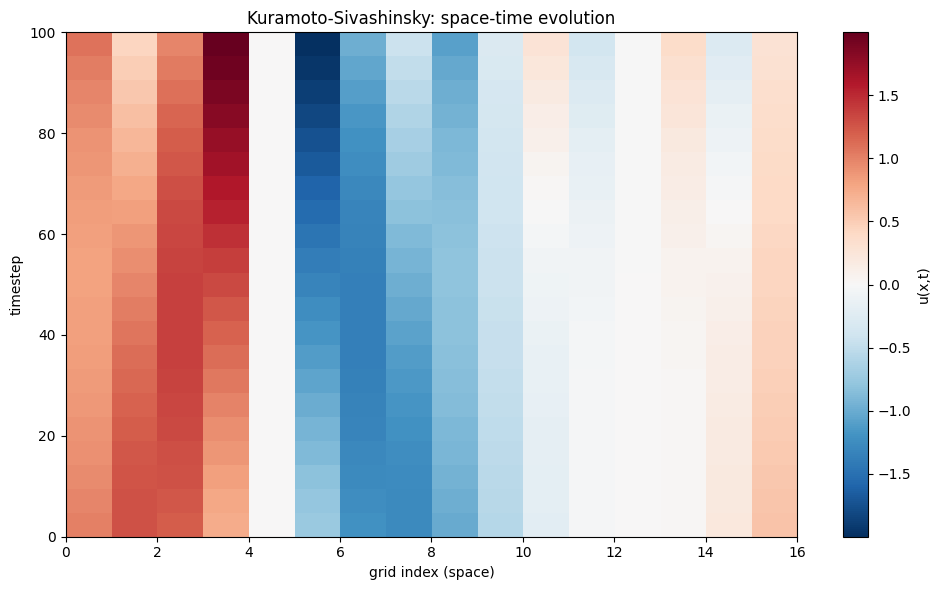

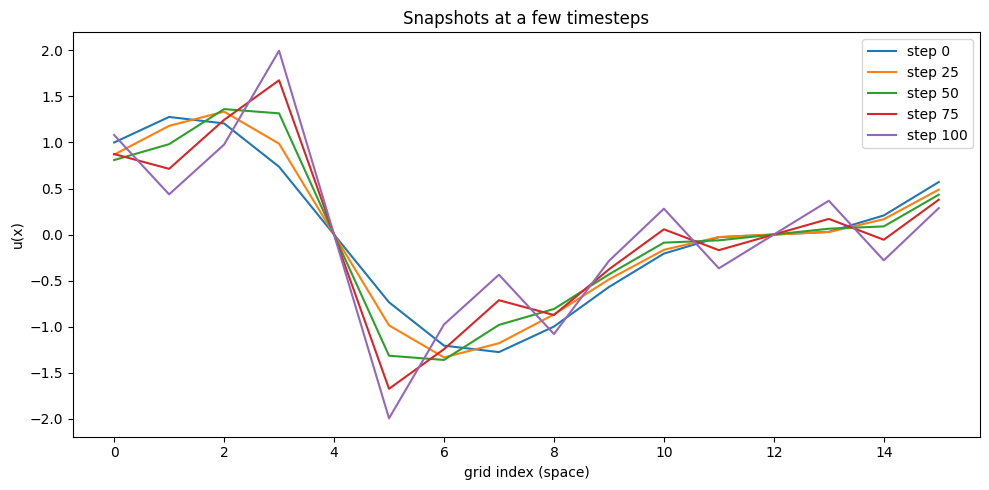

In [15]:
import numpy as np
import matplotlib.pyplot as plt

csvfilename = "kse_quantum.csv"

# Load data directly (bypassing sys.argv for notebook execution)
data = np.loadtxt(csvfilename, delimiter=",")
steps = data[:, 0]           # First column = step number
u = data[:, 1:]              # Remaining columns = u(x) at that step

print(f"Loaded {u.shape[0]} snapshots, {u.shape[1]} grid points each")
print(f"u range: [{u.min():.4f}, {u.max():.4f}]")

# Sanity checks
if np.isnan(u).any() or np.isinf(u).any():
    print("WARNING: NaN or Inf detected in output -- solver blew up.")
if np.max(np.abs(u)) > 1e3:
    print("WARNING: values are very large -- likely unstable / blowing up.")

# --- 1. Space-Time Heatmap ---
plt.figure(figsize=(10, 6))
plt.imshow(
    u,
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    extent=[0, u.shape[1], steps.min(), steps.max()],
)
plt.colorbar(label="u(x,t)")
plt.xlabel("grid index (space)")
plt.ylabel("timestep")
plt.title("Kuramoto-Sivashinsky: space-time evolution")
plt.tight_layout()
plt.show()

# --- 2. Individual Snapshots ---
plt.figure(figsize=(10, 5))
n_snap = min(5, u.shape[0])
idxs = np.linspace(0, u.shape[0] - 1, n_snap, dtype=int)
for i in idxs:
    plt.plot(u[i], label=f"step {int(steps[i])}")
plt.xlabel("grid index (space)")
plt.ylabel("u(x)")
plt.title("Snapshots at a few timesteps")
plt.legend()
plt.tight_layout()
plt.show()